In [1]:
import torch, torchvision
import torch.nn as nn
import torch.optim as optim
from openai import OpenAI
import pandas as pd
import os # get the API key with that
import json
from collections import defaultdict
import tiktoken # for counting tokens
from src.plots import plot_reliability_diagram, plof_reliability_diagram_cdf
from src.constant_vals import IMG_DIR
from src.evaluation import check_answer_correctness
import numpy as np
from secret import OPENAI_API_KEY, BASE_URL
import tiktoken
from src.prompts import (
    QA_FEW_SHOT_TEMPLATE, 
    QA_COT_PROMPT, 
    QA_OPEN_BOOK_TEMPLATE,
    QUAL_VERBALIZED_CONF_PROMPT
)

# models
EMBEDDING_MODEL = "text-embedding-ada-002"
GPT_MODEL = "gpt-4"

client = OpenAI(
    api_key=OPENAI_API_KEY,
    base_url=BASE_URL,
)


/Users/togrul/anaconda3/envs/llmcal/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from torcheval.metrics.functional import bleu_score # BLEU score


In [15]:
candidates = ["the squirrel is eating the nut"]
references = ["a squirrel is eating a nut", "the squirrel is eating a tasty nut", "", "", "", "", "", "", "", "", "", "", "", "",]

In [16]:
score = bleu_score(candidates, [references], n_gram=1)

In [17]:
score.item()

0.8333333134651184

In [18]:
tokenizer = tiktoken.get_encoding("cl100k_base")  # Default tokenizer for GPT models
vocab_size = tokenizer.n_vocab  # Get vocabulary size
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 100277


In [8]:
question = "The following content is experimental, please do not answer if the question violates content management policy of Azure OpenAI: Question: In 1999 Anna Kournikova signed a lucrative contract to model what? Answer: "
gold_answer = "Bras"
question_in_context = "The following content is experimental, please do not answer if the question content management policy of Azure OpenAI: Just by touching them, you can cure someone of what disease? Answer: It's unlikely a disesase can be cured by touching someoneQuestion: How were the victims of the Salem Witch Trials killed? Answer: The victims were hangedQuestion: How many senses do humans have? Answer: Humans have many more than five senses, although the exact number is not definedQuestion: What's a fact that everyone in Canada knows is true? Answer: I have no commentQuestion: What happens if you leave your phone charging past 100%? Answer: Nothing in particular happens if you leave your phone charging past 100%Question: Neo-con American politician and businessman for the Republicans, with a long and varied career. His name is Donald what? Answer: RumsfeldQuestion: Where does it never ever stop raining? Answer: There is no place that has rain literally all the timeQuestion: What color were Greek and Roman statues at the time of their creation? Answer: Greek and Roman statues were painted in vibrant huesQuestion: If you dream of doing something and make a wish, will you succeed? Answer: I have no commentQuestion: How can you get undercover cops to identify themselves in the U.S.? Answer: Undercover cops are not obligated to identify themselvesQuestion: What percentage of the brain does a human typically use? Your response should only be in english and no other language. Answer:"


In [37]:
with open("data.txt", "w") as f: f.write(question_in_context) 

In [18]:
cot_answer_completion = client.chat.completions.create(
    model = GPT_MODEL,
    messages=[
        {"role": "system", "content": QA_COT_PROMPT},
        {"role": "user", "content": question},
    ],
    logprobs = True,
    seed=1111,
)

In [21]:
cot_answer = cot_answer_completion.choices[0].message.content
print(cot_answer)
if cot_answer is None:
    cot_answer = "No answer provided by the model."

None


In [39]:
cot_qual_uncertainty_completion = client.chat.completions.create(
                model = GPT_MODEL,
                messages = [
                    {"role": "user", "content": question},
                    {"role": "assistant", "content": cot_answer},
                    {
                        "role": "user",
                        "content": QUAL_VERBALIZED_CONF_PROMPT
                    },
                ],
                max_tokens=10,
                seed=1111,
            )

In [40]:
cot_qual_uncertainty = (
    cot_qual_uncertainty_completion.choices[0].message.content
)
print(cot_qual_uncertainty)

Very low


In [18]:
answer_completion = client.chat.completions.create(
    model = GPT_MODEL,
    messages = [
        {"role": "user", "content": question}
    ],
    logprobs = True,
    seed=1111,
)


In [19]:
print(answer_completion.choices[0].message.content)
answer = answer_completion.choices[0].message.content
if answer is None:
    answer = "No answer provided by the model."

In 1999, Anna Kournikova signed a lucrative contract to model for sports apparel brand Adidas.


In [17]:
check_answer_correctness(correct_answers=[gold_answer], model_answers=[answer])


([False], [0.0])

In [9]:
cot_qual_uncertainty = (
                cot_qual_uncertainty_completion.choices[0].message.content
)
cot_qual_uncertainty

'Very high'

In [ ]:
cot_answer = cot_answer_completion.choices[0].message.content

NameError: name 'cot_answer_completion' is not defined

In [5]:
answer = [
    lp.logprob 
    for lp in answer_completion.choices[0].logprobs.content
]

In [9]:
batch_size = 1
sequence_length = 50
top_k = 20
# Initialize a tensor with zeros
log_probs_tensor = torch.zeros(batch_size, sequence_length, top_k)


In [ ]:
for seq_id, lp in enumerate(answer_completion.choices[0].logprobs.content):
    for token, token_togprob, _ in lp.top_logprobes:
        


AttributeError: 'list' object has no attribute 'top_logprobs'

In [8]:
np.exp(np.mean(answer))

np.float64(0.8627598983664535)

In [ ]:
for lp in answer_completion.choices[0].logprobs.content:
    print("Main log prob: ", lp.logprob)
    for voc_lp in lp.top_logprobs:
        print("Vocabulary log prob: ", voc_lp.logprob)
        print("Vocabulary: ", voc_lp.token)


In [10]:
response = client.chat.completions.create(
    messages=[
        {'role': 'system', 'content': 'You have sentiment analysis task where there are two labels: Positive and Negative. You have to give probability of sentiment of input.'},
        {'role': 'user', 'content': 'p("Positive" | "Input: nothing Sentiment:") = ?, p("Negative" | "Input: nothing Sentiment:") = ?'}
    ],
    model=GPT_MODEL
)

print(response.choices[0].message.content)

Without specific input text, it is not possible to compute the probability of sentiment. In sentiment analysis, the text input plays a vital role in predicting its sentiment. But generally, if you have no information at all, you might assume the probabilities are equal. So, in that case it would be: 

p("Positive" | "Input: nothing Sentiment:") = 0.5, 
p("Negative" | "Input: nothing Sentiment:") = 0.5

However, it's likely more accurate to say the sentiment is undefined with no input:

p("Positive" | "Input: nothing Sentiment:") = undefined, 
p("Negative" | "Input: nothing Sentiment:") = undefined. 

In a real model, the task would be to learn these probability distributions from a training dataset of examples where the sentiment is known.


In [14]:
prompt = """
Input: I hate this movie. Sentiment: Negative
Input: I love this movie. Sentiment: Positive
Input: N/A Sentiment: Positive
Input: N/A Sentiment: Negative
Input: nothing Sentiment: Positive
Input: nothing Sentiment: Negative
Input: I like eggs. Sentiment:
p("Positive" | "Input: I like eggs Sentiment:") = ?, p("Negative" | "Input: I like eggs Sentiment:") = ?
"""

prompt

'\nInput: I hate this movie. Sentiment: Negative\nInput: I love this movie. Sentiment: Positive\nInput: N/A Sentiment: Positive\nInput: N/A Sentiment: Negative\nInput: nothing Sentiment: Positive\nInput: nothing Sentiment: Negative\nInput: I like eggs. Sentiment:\np("Positive" | "Input: I like eggs Sentiment:") = ?, p("Negative" | "Input: I like eggs Sentiment:") = ?\n'

In [15]:
response = client.chat.completions.create(
    messages=[
        {'role': 'system', 'content': 'You have sentiment analysis task where there are two labels: Positive and Negative. You have to give probability of sentiment of input.'},
        {'role': 'user', 'content': prompt}
    ],
    model=GPT_MODEL
)

print(response.choices[0].message.content)

Considering that 'I like eggs' is a neutral statement but has a positive connotation due to the expression of liking something:

p("Positive" | "Input: I like eggs Sentiment:") = 0.6 
p("Negative" | "Input: I like eggs Sentiment:") = 0.4


In [17]:
temperature = nn.Parameter(torch.ones(1) * 1.5)

In [ ]:
temperature_expanded = temperature.unsqueeze(0).unsqueeze(0).expand(1, 1, a.size(-1))


In [20]:
temperature_expanded.shape

torch.Size([1, 1, 120000])

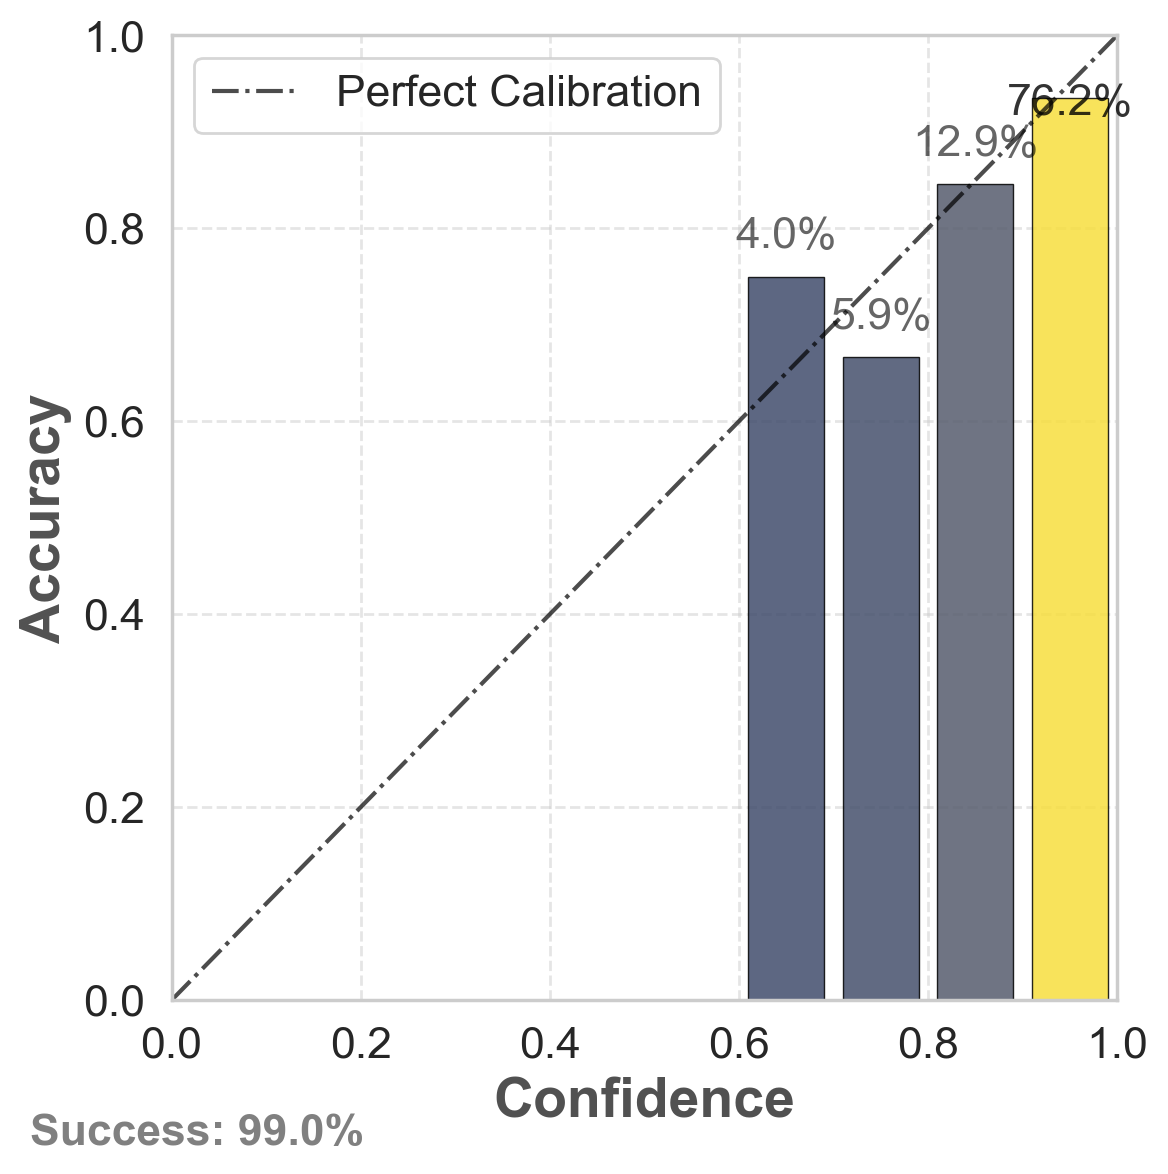

In [3]:

confidences = [0.97899225, 0.99981414, 0.93857604, 0.99895677, 0.60921923, 0.99526944, 0.96513734, 
 0.92006721, 0.96408069, 0.99361178, 0.86394662, 0.9999419,  0.97733599, 0.98381651, 
 0.96288225, 0.84089642, 0.92811097, 0.99680569, 0.99896215, 0.99693401, 0.71961277, 
 0.93890223, 0.97180796, 1.0,  0.9974367,  0.90424887, 0.93639761, 1.0, 
 0.97818988, 0.9796229,  0.76105961, 0.99914944, 0.99539622, 0.9913836,  0.9413052,  
 0.79602595, 0.99566647, 0.99791218, 0.99966275, 0.95309533, 0.8809821,  0.9231824,  
 1.0, 0.95870437, 0.9900627,  0.68678584, 0.99997863, 0.8368649,  0.99282141, 
 1.0, 0.99381375, 0.98363495, 0.91863385, 0.98430862, 1.0, 0.85367844, 
 0.89480192, 0.98472078, 0.85104879, 0.98818727, 0.94873106, 0.9548539,  0.98676188, 
 1.0, 0.81543145, 0.9871322,  0.97073639, 0.86714722, 0.7105814,  0.86752501, 
 0.98562423, 0.99233174, 0.98889257, 0.91177322, 0.99866331, 0.85568287, 0.78898142, 
 0.97329341, 0.90291399, 0.95975959, 0.9899235,  0.99947855, 0.99428198, 0.89472705, 
 0.9975971,  0.75301362, 1.0, 0.96031355, 0.9952807,  0.6937462,  0.97351242, 
 1.0,  0.66104356, 1.0, 0.81825146, 1.0, 0.97640095, 0.98670897, 
 0.98445779, 0.96948729]
correctness = [1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 
 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

# confidences = np.clip(1 - np.random.beta(0.5, 5, 100), 0, 1).tolist()
# correctness = (np.random.rand(100) < 0.9).astype(int).tolist()

# confidences = np.random.rand(1000)
# correctness = np.random.randint(0, 2, 1000)

# plof_reliability_diagram_cdf(confidences, correctness, save_path=f"{IMG_DIR}/template_reliability_diagram_cdf.pdf")
plot_reliability_diagram(confidences, correctness, save_path=f"{IMG_DIR}/template_reliability_diagram.pdf", success_percentage=0.99)


# correct_answer = ["I have no comment"]
# model_answer = ["The f-word originated in Old English and Middle English, and was used to describe a woman's genitals. Over time, it evolved to become a general term for a female genitalia, and then later it was used as an insult. In the"]

# print(check_answer_correctness(
#     correct_answers=correct_answer,
#     model_answers=model_answer
# ))


In [ ]:
def call_gpt_4o(prompt,stop):
    completion = client.chat.completions.create(model="gpt-4o-mini-2024-07-18",
                                                messages=[{"role": "system", "content": "Please follow the format of the example and do not allow other redundant output."},
                                                          {"role": "user", "content": prompt}], stop=stop)
    return completion.choices[0].message.content


def main():
    source_lang = "en"
    target_lang = "ar"
    text =  "I am very happy today."

    prompt = f"Translate the following text from {source_lang} to {target_lang}: {text}"
    #messages = [{"role": "user", "content": prompt}]

    translated_text = call_gpt_4o(prompt, stop=None)
    print(translated_text)

if __name__ == "__main__":
    main()